# Breast Cancer Classification (PyTorch, Iris-Style)
Follows the same structure as the Iris classification notebook — with Sigmoid activations and BCELoss.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

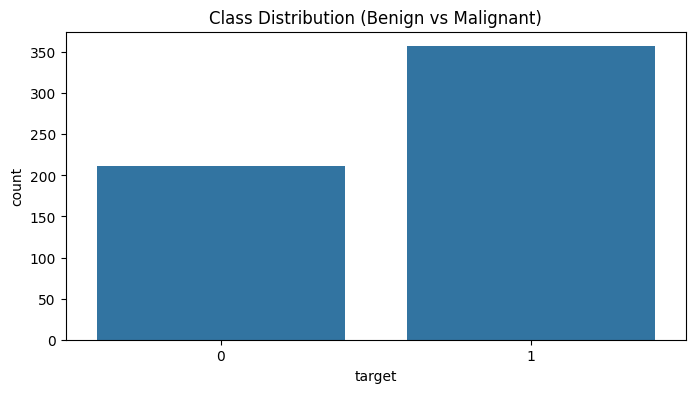

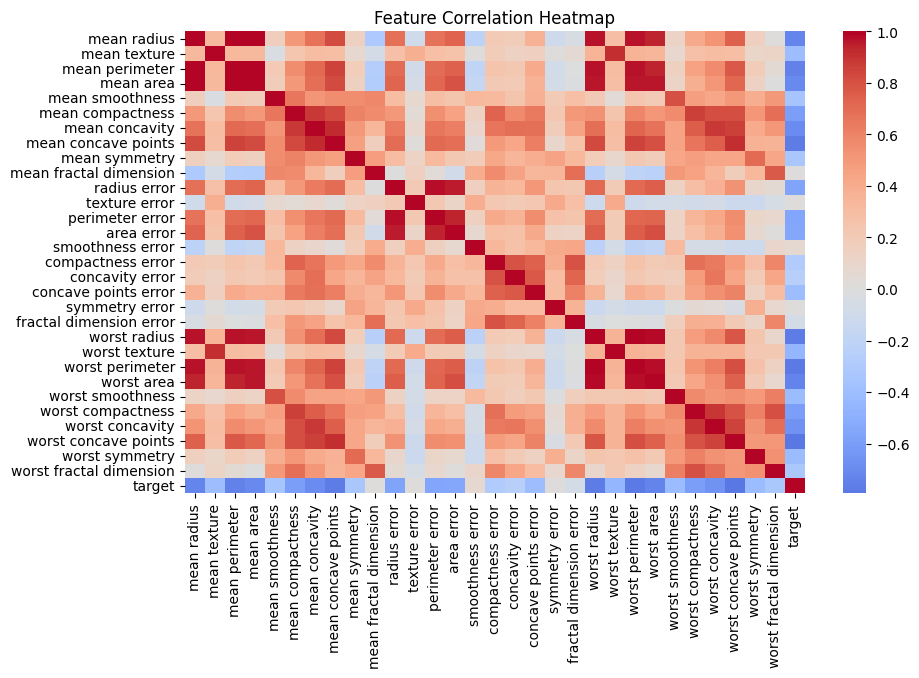

In [ ]:
# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

plt.figure(figsize=(8,4))
sns.countplot(x='target', data=df)
plt.title('Class Distribution (Benign vs Malignant)')
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
# Train/test split and normalization
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

x_means = torch.tensor(scaler.mean_, dtype=torch.float32)
x_stds = torch.tensor(scaler.scale_, dtype=torch.float32)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
test_dl = DataLoader(test_ds, batch_size=64)

In [ ]:
# Define MLP model (Iris style)
class MLP_Net(nn.Module):
    def __init__(self, x_means, x_deviations):
        super().__init__()
        self.x_means = x_means
        self.x_deviations = x_deviations
        self.linear1 = nn.Linear(30, 10)
        self.act1 = nn.Sigmoid()
        self.linear2 = nn.Linear(10, 1)
        self.act2 = nn.Sigmoid()
        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = (x - self.x_means) / self.x_deviations
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout(x)
        x = self.linear2(x)
        y_pred = self.act2(x)
        return y_pred

In [ ]:
# Initialize model, loss, optimizer
model = MLP_Net(x_means, x_stds)
loss_fn = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

def training_loop(N_Epochs, model, loss_fn, opt):
    for epoch in range(N_Epochs):
        for xb, yb in train_dl:
            y_pred = model(xb)
            loss = loss_fn(y_pred, yb)
            opt.zero_grad()
            loss.backward()
            opt.step()
        if epoch % 50 == 0:
            print(epoch, 'loss=', loss.item())

training_loop(300, model, loss_fn, optimizer)

0 loss= 0.650014340877533
50 loss= 0.18146350979804993
100 loss= 0.1692417412996292
150 loss= 0.032828330993652344
200 loss= 0.18232829868793488
250 loss= 0.14184141159057617


Accuracy: 0.956
Precision: 0.972
Recall: 0.958
F1 Score: 0.965


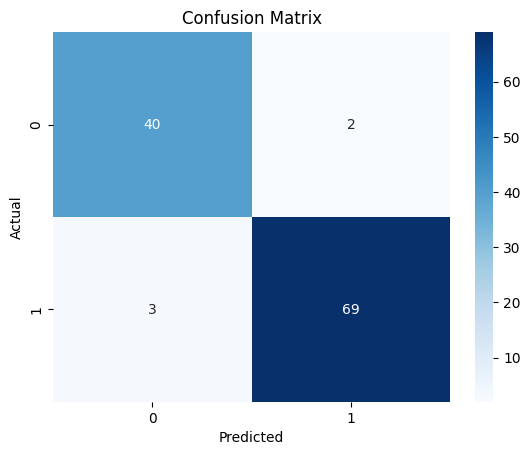

In [ ]:
# Evaluation
model.eval()
with torch.no_grad():
    y_pred = model(X_test_t)
    y_pred_class = (y_pred >= 0.5).int()

acc = accuracy_score(y_test_t, y_pred_class)
prec = precision_score(y_test_t, y_pred_class)
rec = recall_score(y_test_t, y_pred_class)
f1 = f1_score(y_test_t, y_pred_class)
cm = confusion_matrix(y_test_t, y_pred_class)

print(f'Accuracy: {acc:.3f}')
print(f'Precision: {prec:.3f}')
print(f'Recall: {rec:.3f}')
print(f'F1 Score: {f1:.3f}')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

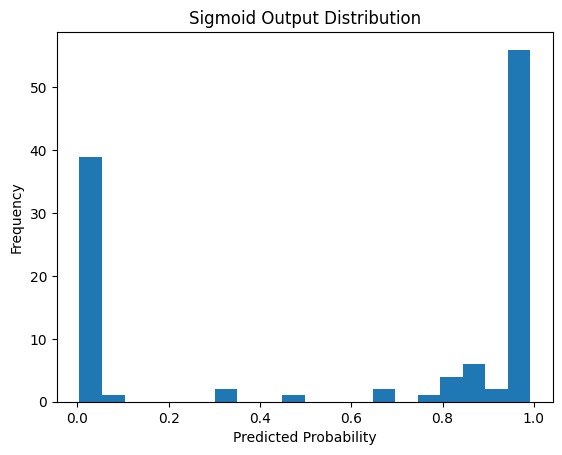

In [ ]:
# Sigmoid output histogram
with torch.no_grad():
    probs = model(X_test_t).numpy().ravel()
plt.hist(probs, bins=20)
plt.title('Sigmoid Output Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')
plt.show()

In [ ]:
!pip install onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 63.6 MB/s eta 0:00:00


In [ ]:
# Export model to ONNX
dummy_input = torch.randn(1, 30)
torch.onnx.export(model, dummy_input, 'BreastCancer_MLP.onnx',
                  input_names=['input'], output_names=['output'],
                  dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
                  opset_version=17)
print('Model exported to BreastCancer_MLP.onnx')

Model exported to BreastCancer_MLP.onnx


/tmp/ipython-input-2491471343.py:3: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(model, dummy_input, 'BreastCancer_MLP.onnx',


In [ ]:
!pip install onnx onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 49.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.4 MB/s eta 0:00:00


In [ ]:
import onnx
import onnxruntime as ort
import numpy as np

# --- Load and verify structure ---
onnx_model = onnx.load("BreastCancer_MLP.onnx")
onnx.checker.check_model(onnx_model)
print("ONNX model loaded and structure verified!")

# --- Create ONNX runtime session ---
session = ort.InferenceSession("BreastCancer_MLP.onnx")

# --- Test with one sample from your dataset ---
# (Use an existing scaled test sample)
X_test_sample = X_test_t[:1].numpy().astype(np.float32)

# Run inference
result = session.run(None, {"input": X_test_sample})
pred = result[0][0][0]
print("Predicted output (Sigmoid probability):", pred)
print("Predicted class:", "Benign" if pred >= 0.5 else "Malignant")


ONNX model loaded and structure verified!
Predicted output (Sigmoid probability): 0.0043136775
Predicted class: Malignant


In [ ]:
# Run batch predictions
X_batch = X_test_t[:10].numpy().astype(np.float32)
y_true  = y_test_t[:10].numpy().ravel()

results = session.run(None, {"input": X_batch})[0].ravel()
pred_classes = (results >= 0.5).astype(int)

for i, (prob, pred, true) in enumerate(zip(results, pred_classes, y_true)):
    print(f"Sample {i}: Prob={prob:.3f}, Pred={pred}, Actual={int(true)}")


Sample 0: Prob=0.004, Pred=0, Actual=0
Sample 1: Prob=0.992, Pred=1, Actual=1
Sample 2: Prob=0.029, Pred=0, Actual=0
Sample 3: Prob=0.851, Pred=1, Actual=1
Sample 4: Prob=0.004, Pred=0, Actual=0
Sample 5: Prob=0.971, Pred=1, Actual=1
Sample 6: Prob=0.992, Pred=1, Actual=1
Sample 7: Prob=0.004, Pred=0, Actual=0
Sample 8: Prob=0.004, Pred=0, Actual=0
Sample 9: Prob=0.004, Pred=0, Actual=0


In [ ]:
from google.colab import files
files.download("BreastCancer_MLP.onnx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import onnxruntime as ort
import numpy as np
from sklearn.datasets import load_breast_cancer

# Load ONNX model and feature names
session = ort.InferenceSession("BreastCancer_MLP.onnx")
data = load_breast_cancer()
feature_names = list(data.feature_names)

# --- Prediction function ---
def predict(*features):
    x = np.array(features, dtype=np.float32).reshape(1, -1)
    y = session.run(None, {"input": x})[0][0][0]
    label = "Benign 🩷" if y >= 0.5 else "Malignant 💀"
    return f"**Predicted Class:** {label}\n**Probability (Benign):** {y:.3f}"

# --- Build Gradio UI ---
inputs = [gr.Number(label=feature) for feature in feature_names]

demo = gr.Interface(
    fn=predict,
    inputs=inputs,
    outputs="markdown",
    title="🩺 Breast Cancer Classification (ONNX Model)",
    description="Enter the 30 numeric features from the Breast Cancer Wisconsin dataset to predict whether the tumor is **Benign** or **Malignant**.",
)

demo.launch(share=True, debug=True)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a6d0cb9ce4ce7ad9e3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7861 <> https://a6d0cb9ce4ce7ad9e3.gradio.live
